# Predicting Student Performance From Quantitative and Qualitative Factors

## 1. Dataset Description & Schema Summary

> [Student Performance Factors - Kaggle](https://www.kaggle.com/datasets/ayeshasiddiqa123/student-perfirmance)

### About Dataset

Context :

The purpose of this dataset is to examine the major variables that affect students' academic achievement, especially their test results. It focuses on how the educational environment, learning resources, family history, and individual behaviors all influence student results. The dataset is helpful for machine learning models, educational research, and data science initiatives that seek to comprehend academic achievement and spot trends in high and low performance. It is appropriate for exploratory data analysis and predictive modeling since it offers a realistic picture of student life and learning environments.

Content :

Students' study hours, attendance, motivation level, availability to learning resources, parental participation, teacher quality, peer influence, and family background are all included in the dataset. It also include environmental and lifestyle elements including internet availability, sleep patterns, and school type. The dataset can be utilized for performance prediction and educational insights because the goal variable represents students' exam scores. Together, these characteristics create a comprehensive dataset that can be used to analyze the various factors that influence academic attainment.

In [1]:
import pandas as pd

# lets start by exploring the dataset
data = pd.read_csv("StudentPerformanceFactors.csv")

print("rows , cols", data.shape, sep="\n")

rows , cols
(6607, 20)


In [2]:
# creating a mapping of columns, with some helpful descriptions
meaning_map = {
    "Hours_Studied": "Total hours studied (behavior)",
    "Attendance": "Attendance percentage (behavior)",
    "Parental_Involvement": "Level of parental involvement (support factor)",
    "Access_to_Resources": "Level of access to educational resources (support factor)",
    "Extracurricular_Activities": "Participation in extracurricular activities (Yes/No)",
    "Sleep_Hours": "Average sleep hours (behavior/health)",
    "Previous_Scores": "Prior test scores (baseline achievement)",
    "Motivation_Level": "Self-reported motivation level (subjective)",
    "Internet_Access": "Internet access (Yes/No)",
    "Tutoring_Sessions": "Number of tutoring sessions",
    "Family_Income": "Family income level (socioeconomic indicator)",
    "Teacher_Quality": "Perceived/assigned teacher quality level",
    "School_Type": "Type of school (Public/Private)",
    "Peer_Influence": "Peer influence category (Positive/Neutral/Negative)",
    "Physical_Activity": "Physical activity level/frequency (numeric scale)",
    "Learning_Disabilities": "Learning disabilities (Yes/No)",
    "Parental_Education_Level": "Highest parental education level",
    "Distance_from_Home": "Distance from home to school (Near/Moderate/Far)",
    "Gender": "Student gender",
    "Exam_Score": "Final exam score (outcome)",
}

schema = pd.DataFrame(
    {
        "Column": data.columns,
        "Type": [str(t) for t in data.dtypes],
        "Description": [meaning_map.get(c, "") for c in data.columns],
    }
)

print(schema)

                        Column   Type  \
0                Hours_Studied  int64   
1                   Attendance  int64   
2         Parental_Involvement    str   
3          Access_to_Resources    str   
4   Extracurricular_Activities    str   
5                  Sleep_Hours  int64   
6              Previous_Scores  int64   
7             Motivation_Level    str   
8              Internet_Access    str   
9            Tutoring_Sessions  int64   
10               Family_Income    str   
11             Teacher_Quality    str   
12                 School_Type    str   
13              Peer_Influence    str   
14           Physical_Activity  int64   
15       Learning_Disabilities    str   
16    Parental_Education_Level    str   
17          Distance_from_Home    str   
18                      Gender    str   
19                  Exam_Score  int64   

                                          Description  
0                      Total hours studied (behavior)  
1                    Atten


## 2. Data Cleaning & Preprocessing Steps


### Cleaning Pipeline:

1. Load and inspect the data
2. Check duplicates
3. Standardize column names
4. Fix string formatting
5. Handle missing values
   - Missing values appear in a few categorical columns
     - Number of nulls is low compared to the dataset size
     - Dropping null rows due to small number
6. Correct data types
7. Outlier handling
   - Identify out-of-range values
   - In this dataset, `Exam_Score` has a single value of 101, which is outside an expected 0–100 range.
   - We cap `Exam_Score` at 100 and create a flag to preserve transparency.



In [3]:
df = data.copy()

# drop duplicates
df = df.drop_duplicates()


# standardize column names
def to_snake(s: str) -> str:
    return s.strip().replace(" ", "_").replace("-", "_").lower()


df.columns = [to_snake(c) for c in df.columns]


# clean strings
cat_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()

for c in cat_cols:
    df[c] = df[c].astype("string").str.strip()

# standardize a few "Yes/No" style columns to title case for consistency
for c in ["extracurricular_activities", "internet_access", "learning_disabilities"]:
    if c in df.columns:
        df[c] = df[c].str.title()

# standardize multi-level categories to title case (keeps "High School" nicely as-is if already proper)
for c in [
    "parental_involvement",
    "access_to_resources",
    "motivation_level",
    "family_income",
    "teacher_quality",
    "school_type",
    "peer_influence",
    "distance_from_home",
    "gender",
    "parental_education_level",
]:
    if c in df.columns:
        df[c] = df[c].str.replace(r"\s+", " ", regex=True).str.title()


# drop missing values
df = df.dropna(how="any")


# 5) coerce numeric columns and set categories for categoricals
numeric_cols = [
    "hours_studied",
    "attendance",
    "sleep_hours",
    "previous_scores",
    "tutoring_sessions",
    "physical_activity",
    "exam_score",
]

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Convert categorical columns to category dtype
cat_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()
for c in cat_cols:
    df[c] = df[c].astype("category")


# Outlier handling: cap exam_score at 100 if above expected maximum
df["exam_score_capped_flag"] = (df["exam_score"] > 100).astype(int)
df["exam_score"] = df["exam_score"].clip(upper=100)

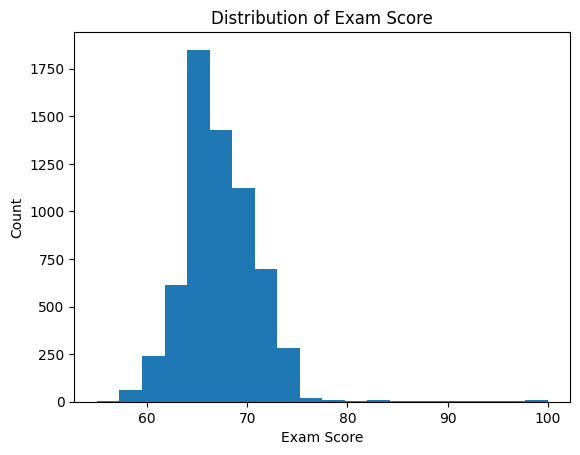

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["exam_score"], bins=20)
plt.title("Distribution of Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Count")
plt.show()

Exam scores cluster tightly around the mid-to-high 60s, with relatively limited spread. since the distribution is fairly concentrated, small differences in behaviors or support factors could still be meaningful when comparing groups

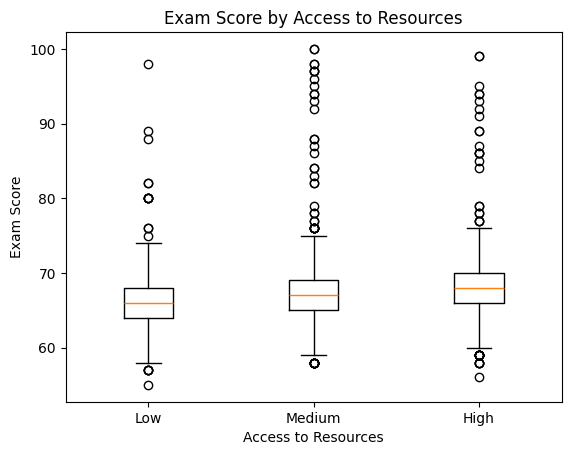

In [5]:
plt.figure()
# Prepare boxplot groups
order = ["Low", "Medium", "High"]
groups = [
    df.loc[df["access_to_resources"] == o, "exam_score"]
    for o in order
    if o in df["access_to_resources"].cat.categories
]
plt.boxplot(
    groups,
    tick_labels=[o for o in order if o in df["access_to_resources"].cat.categories],
)
plt.title("Exam Score by Access to Resources")
plt.xlabel("Access to Resources")
plt.ylabel("Exam Score")
plt.show()

Students with higher access to resources seem to show higher median exam scores, and the score distribution can differ by group.

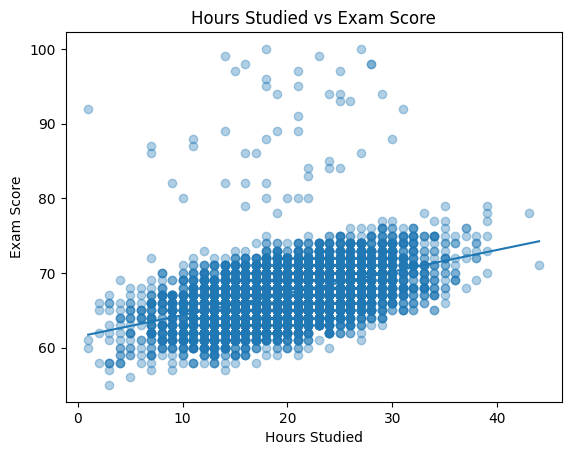

(np.float64(0.29104698706108706), np.float64(61.43768253223566))

In [6]:
import numpy as np

plt.figure()
plt.scatter(df["hours_studied"], df["exam_score"], alpha=0.35)
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

# Add trend line
m, b = np.polyfit(df["hours_studied"], df["exam_score"], 1)
x = np.linspace(df["hours_studied"].min(), df["hours_studied"].max(), 100)
plt.plot(x, m * x + b)
plt.show()

m, b


There is a positive association between hours studied and exam score. While the relationship is not exact, the direction aligns with the expectation that greater study time relates to better outcomes.


## 4. Ethical, De-identification, & Data Quality Concerns


### De-identification / sensitive fields
- The dataset contains no direct personal identifiers (no names, addresses, phone numbers, student IDs, or dates of birth).
- It does include sensitive socioeconomic and educational context variables, such as:
  - `family_income`
  - `parental_education_level`
  - `learning_disabilities`
  - `access_to_resources`
  - `internet_access`

These fields can be sensitive because they relate to socioeconomic status and disability status. Even without direct identifiers, such variables can contribute to ethical risks if used without care.

### Quasi-identifiers
There are no obvious quasi-identifiers like ZIP codes, exact birth dates, or fine-grained location data. The closest is `distance_from_home` which is coarse (Near/Moderate/Far), reducing re-identification risk.

### Data quality limitations
- Missing data: A few categorical columns had missing values (`teacher_quality`, `parental_education_level`, `distance_from_home`).  
  - this was handled this by dropping the missing rows, since the number of missing values was small.
- Subjective measures: Variables like `motivation_level` and `peer_influence` are likely subjective and may be measured inconsistently.
- Potential bias & confounding: Socioeconomic indicators are correlated with many other opportunities
  - For example, higher income may be correlated to a higher score. However, this could be due to confounding of other variables like better resources, tutoring and parental education.

### Outliers and integrity
- one `exam_score` had a value of 101 (above a typical maximum of 100).  
  - scores were capped at 100 and preserved transparency using `exam_score_capped_flag`.


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.svm import SVR
from xgboost import XGBRegressor

# reproducibility
SEED = 42
np.random.seed(SEED)

# define target and features
target = "exam_score"

X = df.drop(columns=[target])
y = df[target]


# train / validation / test split
# 70% train / 15% validation / 15% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,  # gives ~15% of total dataset
    random_state=SEED,
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)


# identify numeric and categorical columns
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()


# detect highly skewed numeric features
# (used for log transformation)
skew_vals = X_train[numeric_cols].skew().abs()

log_transform_cols = skew_vals[skew_vals > 1].index.tolist()
normal_numeric_cols = [c for c in numeric_cols if c not in log_transform_cols]

print("Columns log-transformed:", log_transform_cols)


# define log transform function
# log1p handles zero values safely
log_transformer = FunctionTransformer(np.log1p, validate=False)


# numeric pipelines

# pipeline for skewed columns
log_numeric_pipeline = Pipeline(
    [("log_transform", log_transformer), ("scaler", StandardScaler())]
)

# pipeline for regular numeric columns
numeric_pipeline = Pipeline([("scaler", StandardScaler())])


# categorical pipeline
categorical_pipeline = Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore"))])


# column transformer
# applies appropriate preprocessing to each column group
preprocessor = ColumnTransformer(
    [
        ("log_num", log_numeric_pipeline, log_transform_cols),
        ("num", numeric_pipeline, normal_numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ]
)


# svm pipeline
svm_pipeline = Pipeline([("preprocess", preprocessor), ("model", SVR())])


# xgboost pipeline
xgb_pipeline = Pipeline(
    [
        ("preprocess", preprocessor),
        (
            "model",
            XGBRegressor(random_state=SEED, objective="reg:squarederror", n_jobs=-1),
        ),
    ]
)


# hyperparameter grids

svm_param_grid = {
    "model__kernel": ["rbf", "linear"],
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", "auto"],
}

xgb_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 6, 10],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}


# grid search with validation split

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)


# train models
print("\nTraining SVM...")
svm_grid.fit(X_train, y_train)

print("\nTraining XGBoost...")
xgb_grid.fit(X_train, y_train)


# print best hyperparameters
print("\nBest SVM Parameters:")
print(svm_grid.best_params_)

print("\nBest XGBoost Parameters:")
print(xgb_grid.best_params_)


# validation performance
svm_val_preds = svm_grid.predict(X_val)
xgb_val_preds = xgb_grid.predict(X_val)

print("\n================ VALIDATION METRICS ================\n")

print("SVM Validation Metrics")
print("MAE:", mean_absolute_error(y_val, svm_val_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_val, svm_val_preds)))
print("R2:", r2_score(y_val, svm_val_preds))

print("\nXGBoost Validation Metrics")
print("MAE:", mean_absolute_error(y_val, xgb_val_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_val, xgb_val_preds)))
print("R2:", r2_score(y_val, xgb_val_preds))


# final model selection
# choose model with lower validation RMSE
svm_rmse = np.sqrt(mean_squared_error(y_val, svm_val_preds))
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_val_preds))

best_model = svm_grid if svm_rmse < xgb_rmse else xgb_grid

print(
    "\nBest model selected:",
    type(best_model.best_estimator_.named_steps["model"]).__name__,
)


# retrain best model on train + validation
best_model.fit(X_train_val, y_train_val)


# final test evaluation (unseen data)
test_preds = best_model.predict(X_test)

mae = mean_absolute_error(y_test, test_preds)
rmse = np.sqrt(mean_squared_error(y_test, test_preds))
r2 = r2_score(y_test, test_preds)

print("\n================ FINAL TEST METRICS ================\n")

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


# visualize predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_preds)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Predicted vs Actual (Test Set)")
plt.show()

Train size: (4464, 20)
Validation size: (957, 20)
Test size: (957, 20)
Columns log-transformed: ['exam_score_capped_flag']

Training SVM...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Training XGBoost...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
